<a href="https://colab.research.google.com/github/Grashch/Kaggle_tasks/blob/main/SHAP_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap

data = pd.read_csv('/content/FIFA 2018 Statistics.csv')
y = (data['Man of the Match'] == "Yes")  # Convert from string "Yes"/"No" to binary
feature_names = [i for i in data.columns if data[i].dtype in [np.int64, np.int64]]
X = data[feature_names]
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
my_model = RandomForestClassifier(random_state=0).fit(train_X, train_y)

In [19]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.1 MB/s eta 0:00:00


In [27]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(my_model, random_state=1)
perm.fit(train_X, train_y)
eli5.show_weights(perm, feature_names=X.columns.tolist())

Weight,Feature
0.1375 ± 0.0243,Goal Scored
0.0187 ± 0.0156,Attempts
0.0104 ± 0.0132,Free Kicks
0.0104 ± 0.0000,Blocked
0.0083 ± 0.0083,Distance Covered (Kms)
0.0062 ± 0.0102,On-Target
0.0062 ± 0.0102,Pass Accuracy %
0.0042 ± 0.0102,Ball Possession %
0.0021 ± 0.0083,Fouls Committed
0.0021 ± 0.0083,Corners


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    128 non-null    object 
 1   Team                    128 non-null    object 
 2   Opponent                128 non-null    object 
 3   Goal Scored             128 non-null    int64  
 4   Ball Possession %       128 non-null    int64  
 5   Attempts                128 non-null    int64  
 6   On-Target               128 non-null    int64  
 7   Off-Target              128 non-null    int64  
 8   Blocked                 128 non-null    int64  
 9   Corners                 128 non-null    int64  
 10  Offsides                128 non-null    int64  
 11  Free Kicks              128 non-null    int64  
 12  Saves                   128 non-null    int64  
 13  Pass Accuracy %         128 non-null    int64  
 14  Passes                  128 non-null    in

In [17]:
data_for_prediction = val_X.iloc[0,:]  # use 1 row of data here. Could use multiple rows if desired

# Create object that can calculate shap values
explainer = shap.TreeExplainer(my_model)
shap_values = explainer.shap_values(data_for_prediction)
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0], data_for_prediction)

DimensionError: Length of features is not equal to the length of shap_values!

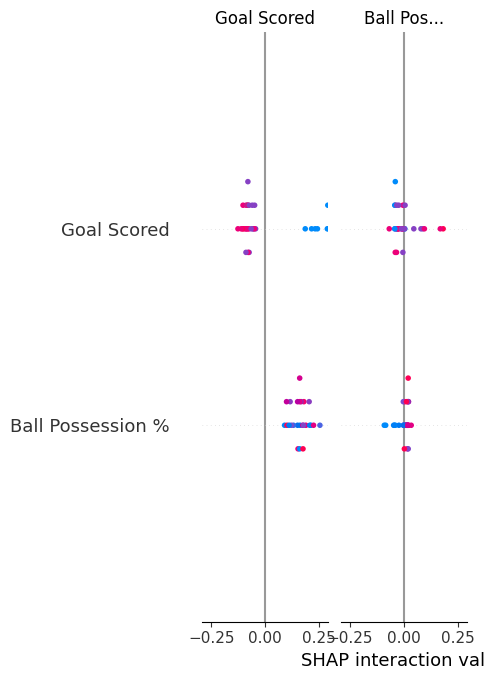

In [7]:

# --- 3. Создаём SHAP-эксплайнер ---
# TreeExplainer оптимизирован для деревьев решений (RandomForest, XGBoost и т. п.)
explainer = shap.TreeExplainer(my_model)
# --- 4. Вычисляем SHAP-значения для всех данных ---
shap_values = explainer.shap_values(val_X)
# --- 5. Визуализируем результаты ---
# 5.1. Summary Plot: кто в среднем важнее
shap.summary_plot(shap_values, val_X, plot_type="bar")
# → Столбцы: средняя абсолютная SHAP‑величина для каждого признака
#   Чем выше столбец, тем важнее признак в целом.

In [5]:
shap_values

array([[[ 2.44655453e-01, -2.44655453e-01],
        [-4.51643485e-03,  4.51643485e-03],
        [ 4.09647280e-02, -4.09647280e-02],
        ...,
        [-5.15813494e-05,  5.15813494e-05],
        [-3.33559236e-04,  3.33559236e-04],
        [ 2.61738966e-03, -2.61738966e-03]],

       [[ 2.81067741e-01, -2.81067741e-01],
        [-2.62894943e-03,  2.62894943e-03],
        [-2.34948511e-02,  2.34948511e-02],
        ...,
        [-7.02780011e-05,  7.02780011e-05],
        [-3.65077246e-04,  3.65077246e-04],
        [ 2.60016180e-03, -2.60016180e-03]],

       [[-9.10739341e-02,  9.10739341e-02],
        [ 1.09088587e-02, -1.09088587e-02],
        [-8.22729477e-02,  8.22729477e-02],
        ...,
        [-4.23431067e-04,  4.23431067e-04],
        [-1.17969059e-03,  1.17969059e-03],
        [ 1.62331476e-03, -1.62331476e-03]],

       ...,

       [[ 2.73349131e-01, -2.73349131e-01],
        [-4.79318391e-03,  4.79318391e-03],
        [-3.79563945e-02,  3.79563945e-02],
        ...,
     

ValueError: x and y must be the same size

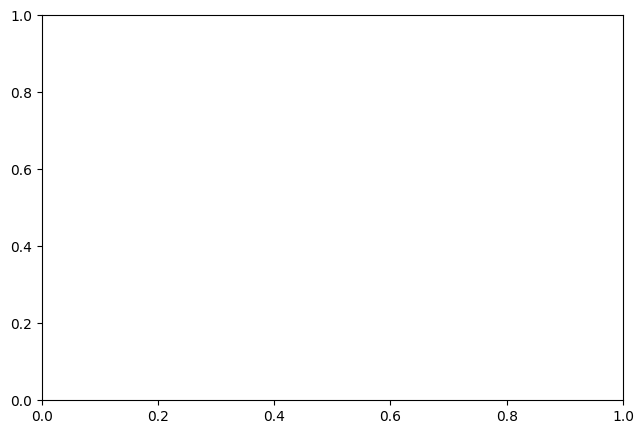

In [9]:
# 5.2. Dependence Plot: как один признак влияет на прогноз
shap.dependence_plot(
    'Goal Scored',      # какой признак анализируем
    shap_values,       # SHAP‑значения
    val_X,                 # исходные данные
    interaction_index='Yellow & Red'
)

In [ ]:
import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor


# --- 1. Создаём искусственные данные (простой пример) ---
# Представим, что мы предсказываем урожайность поля (в тоннах)
# от трёх факторов: количество дождя, температура, удобрения

np.random.seed(42)  # фиксируем случайность для воспроизводимости

data = pd.DataFrame({
    'Дождь_мм': np.random.normal(50, 15, 100),      # мм осадков
    'Температура_C': np.random.normal(20, 5, 100),     # средняя температура
    'Удобрения_кг': np.random.uniform(0, 100, 100)  # кг на гектар
})

# Целевая переменная: урожайность (зависит от факторов + шум)
# Урожайность растёт с дождём и удобрениями, но есть оптимум по температуре
data['Урожайность_т'] = (
    0.5 * data['Дождь_мм'] +
    2 * data['Удобрения_кг'] +
    -0.1 * (data['Температура_C'] - 22)**2 +  # пик при 22 °C
    np.random.normal(0, 2, 100)  # случайный шум
)

# Разделяем признаки (X) и цель (y)
X = data[['Дождь_мм', 'Температура_C', 'Удобрения_кг']]
y = data['Урожайность_т']


# --- 2. Обучаем модель (случайный лес) ---
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

RandomForestRegressor(n_estimators=50, random_state=42)

/tmp/ipython-input-2925913052.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="bar")


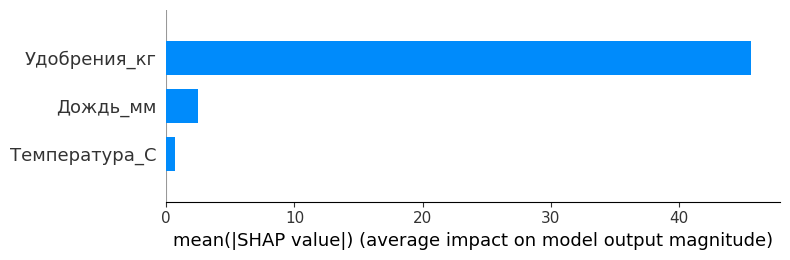

In [ ]:
# --- 3. Создаём SHAP-эксплайнер ---
# TreeExplainer оптимизирован для деревьев решений (RandomForest, XGBoost и т. п.)
explainer = shap.TreeExplainer(model)


# --- 4. Вычисляем SHAP-значения для всех данных ---
shap_values = explainer.shap_values(X)


# --- 5. Визуализируем результаты ---

# 5.1. Summary Plot: кто в среднем важнее
shap.summary_plot(shap_values, X, plot_type="bar")
# → Столбцы: средняя абсолютная SHAP‑величина для каждого признака
#   Чем выше столбец, тем важнее признак в целом.

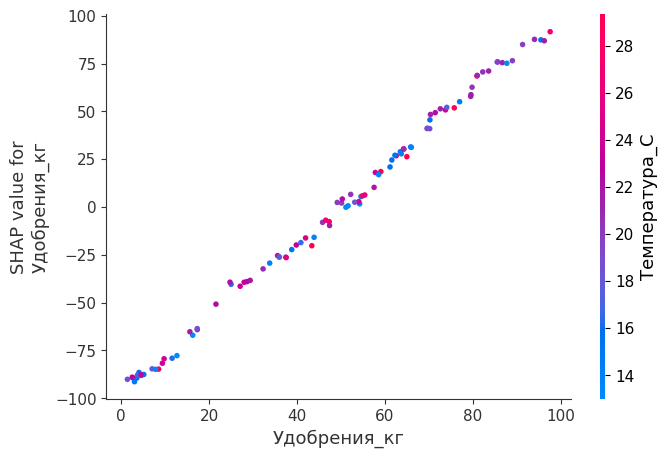

In [ ]:
# 5.2. Dependence Plot: как один признак влияет на прогноз
shap.dependence_plot(
    "Удобрения_кг",      # какой признак анализируем
    shap_values,       # SHAP‑значения
    X,                 # исходные данные
    interaction_index="Температура_C"  # цвет точек — значение этого признака
)
# → График показывает:
#   - По горизонтали: количество удобрений (кг).
#   - По вертикали: SHAP‑значение признака «Удобрения_кг» (его вклад в прогноз).
#   - Цвет точек: температура.
# Если линии для разных температур идут по‑разному — есть взаимодействие.

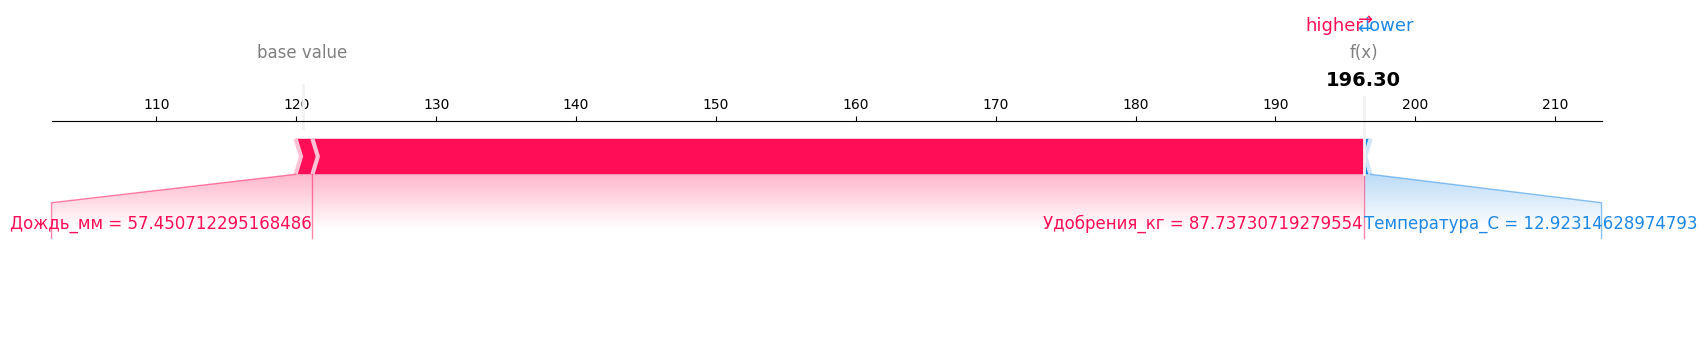

In [ ]:
# 5.3. Force Plot: объяснение прогноза для одного объекта
# Возьмём первую строку данных
data_for_prediction = X.iloc[0:1]  # одна строка (форма: 1×3)


shap_values_single = explainer.shap_values(data_for_prediction)

shap.force_plot(
    explainer.expected_value,  # базовый уровень (средняя урожайность)
    shap_values_single,       # вклад каждого признака для этого объекта
    data_for_prediction,        # значения признаков
    matplotlib=True             # для статичного графика
)
# → На графике:
#   - Слева: базовый прогноз (средняя урожайность по всем полям).
#   - Стрелки вправо (красные): признаки, повышающие прогноз.
#   - Стрелки влево (синие): признаки, снижающие прогноз.
#   - Длина стрелки = величина вклада (SHAP‑значение).

In [ ]:
# --- 6. Что означают SHAP‑значения (на примере одной строки) ---
print("\nПример для первого объекта:")


# Извлекаем скалярное значение из массива (если expected_value — массив)
expected_value_scalar = explainer.expected_value.item()  # или float(explainer.expected_value)


print(f"Базовый уровень (средняя урожайность): {expected_value_scalar:.2f} т")


for i, col in enumerate(X.columns):
    print(f"  Вклад '{col}': {shap_values_single[0][i]:+.3f} т")

print(f"\nИтоговый прогноз: {expected_value_scalar + shap_values_single.sum():.2f} т")


Пример для первого объекта:
Базовый уровень (средняя урожайность): 120.45 т
  Вклад 'Дождь_мм': +1.203 т
  Вклад 'Температура_C': -0.499 т
  Вклад 'Удобрения_кг': +75.152 т

Итоговый прогноз: 196.30 т
